# Email Classification Using Perceptron

In [48]:
!pip install wordcloud


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Reproducibility
np.random.seed(42)

## Load Dataset

In [35]:

df = pd.read_csv('/content/spam_Emails_data.csv')

print("Dataset loaded successfully!")
print("\n" + "="*50)
print("SPAM/HAM DATASET OVERVIEW")
print("="*50)

# Check the actual columns
print(f"Column names: {df.columns.tolist()}")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nClass distribution:")
print(df['label'].value_counts())

print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset loaded successfully!

SPAM/HAM DATASET OVERVIEW
Column names: ['label', 'text']
Dataset shape: (193852, 2)

First 5 rows:
  label                                               text
0  Spam  viiiiiiagraaaa\nonly for the ones that want to...
1   Ham  got ice thought look az original message ice o...
2  Spam  yo ur wom an ne eds an escapenumber in ch ma n...
3  Spam  start increasing your odds of success & live s...
4   Ham  author jra date escapenumber escapenumber esca...

Class distribution:
label
Ham     102160
Spam     91692
Name: count, dtype: int64

Missing values per column:
label    0
text     2
dtype: int64


## EXPLORATORY DATA ANALYSIS

In [60]:

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

Dataset shape: (193852, 5)
Columns: ['label', 'text', 'text_length', 'word_count', 'cleaned_text']
Missing values:
label           0
text            0
text_length     0
word_count      0
cleaned_text    0
dtype: int64

Data types:
label           object
text            object
text_length      int64
word_count       int64
cleaned_text    object
dtype: object


In [50]:
df.head()

,label,text,text_length,word_count
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...,403,60
1,Ham,got ice thought look az original message ice o...,530,60
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...,215,48
3,Spam,start increasing your odds of success & live s...,345,69
4,Ham,author jra date escapenumber escapenumber esca...,3097,467


In [51]:
df.tail()

,label,text,text_length,word_count
193847,Ham,on escapenumber escapenumber escapenumber rob ...,889,164
193848,Spam,we have everything you need escapelong cialesc...,583,52
193849,Ham,hi quick question say i have a date variable i...,627,119
193850,Spam,thank you for your loan request which we recie...,425,69
193851,Ham,this is an automatically generated delivery st...,1416,200


In [52]:
df.describe()

,text_length,word_count
count,1.938520e+05,1.938520e+05
mean,1.812761e+03,2.760345e+02
std,2.659496e+04,3.671754e+03
min,0.000000e+00,0.000000e+00
25%,3.620000e+02,5.500000e+01
50%,8.000000e+02,1.270000e+02
75%,1.803000e+03,2.800000e+02
max,1.151031e+07,1.585483e+06


In [53]:
class_counts = df['label'].value_counts()
print(class_counts)


label
Ham     102160
Spam     91692
Name: count, dtype: int64


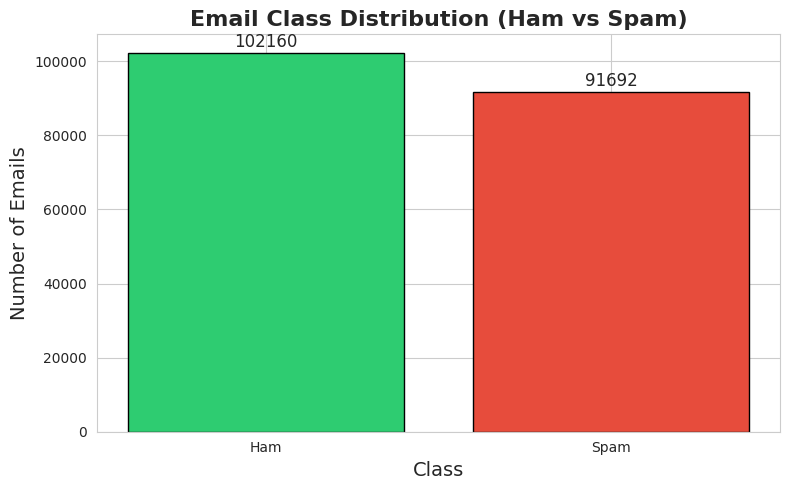

In [42]:
# Visualize class distribution
plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#e74c3c']  # ham=green, spam=red
bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
plt.title('Email Class Distribution (Ham vs Spam)', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Number of Emails', fontsize=14)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()



In [63]:
df['text'] = df['text'].fillna('')
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(f"Average email length (characters): {df['text_length'].mean():.0f}")
print(f"Average word count: {df['word_count'].mean():.0f}")
print(f"Max characters: {df['text_length'].max()}")
print(f"Min characters: {df['text_length'].min()}")

Average email length (characters): 1813
Average word count: 276
Max characters: 11510306
Min characters: 0


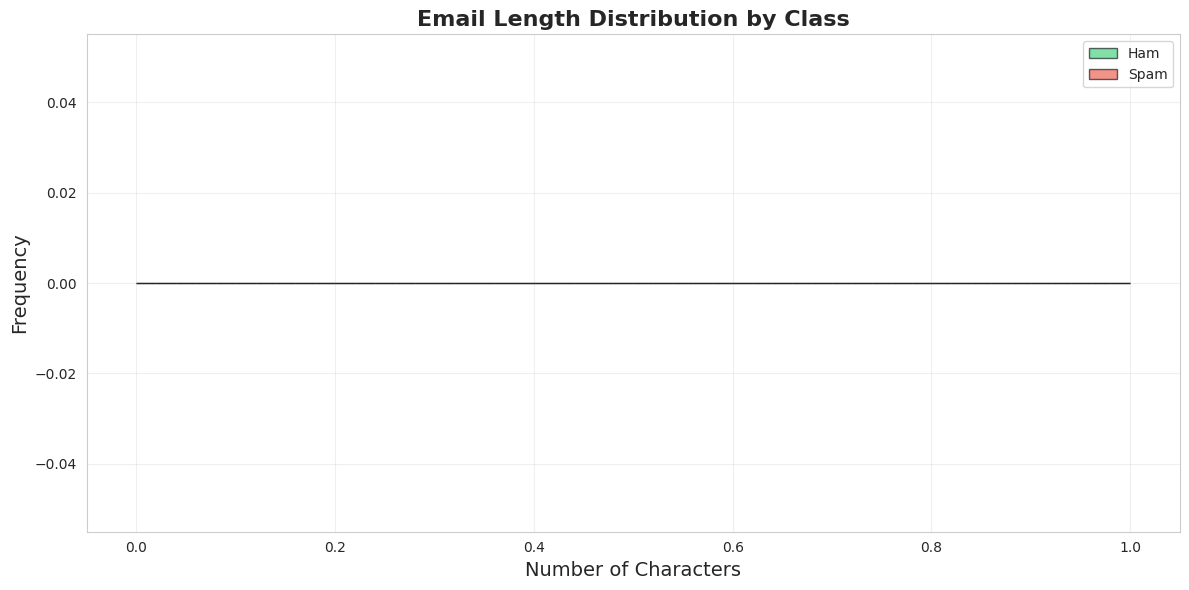

In [62]:
# Histogram of text length by class
plt.figure(figsize=(12,6))
for label, color in zip(['Ham', 'Spam'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]
    plt.hist(subset['text_length'], bins=50, alpha=0.6, label=label, color=color, edgecolor='black')
plt.title('Email Length Distribution by Class', fontsize=16, fontweight='bold')
plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


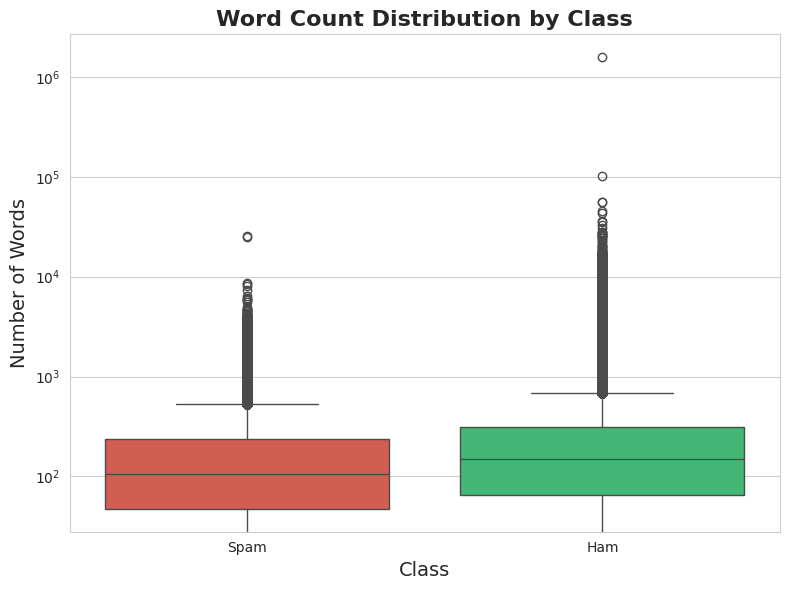

In [46]:
# Boxplot of word count by class
plt.figure(figsize=(8,6))
sns.boxplot(x='label', y='word_count', data=df, palette={'Ham':'#2ecc71', 'Spam':'#e74c3c'})
plt.title('Word Count Distribution by Class', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Number of Words', fontsize=14)
plt.yscale('log')  # log scale because of large outliers
plt.tight_layout()
plt.show()




4. MOST COMMON WORDS
----------------------------------------
Top 15 words in SPAM emails:
  escapenumber: 1114746
  the: 417792
  and: 275651
  escapelong: 251613
  you: 168024
  for: 123061
  cescapenumber: 112614
  bescapenumber: 109666
  your: 107567
  this: 107171
  com: 100038
  http: 87603
  aescapenumber: 79076
  that: 77992
  with: 77139

Top 15 words in HAM emails:
  escapenumber: 2208360
  the: 882566
  and: 381622
  for: 221049
  escapelong: 193700
  enron: 171924
  that: 168247
  com: 159335
  you: 148642
  this: 141631
  from: 122479
  with: 120377
  have: 102068
  http: 96989
  are: 91575


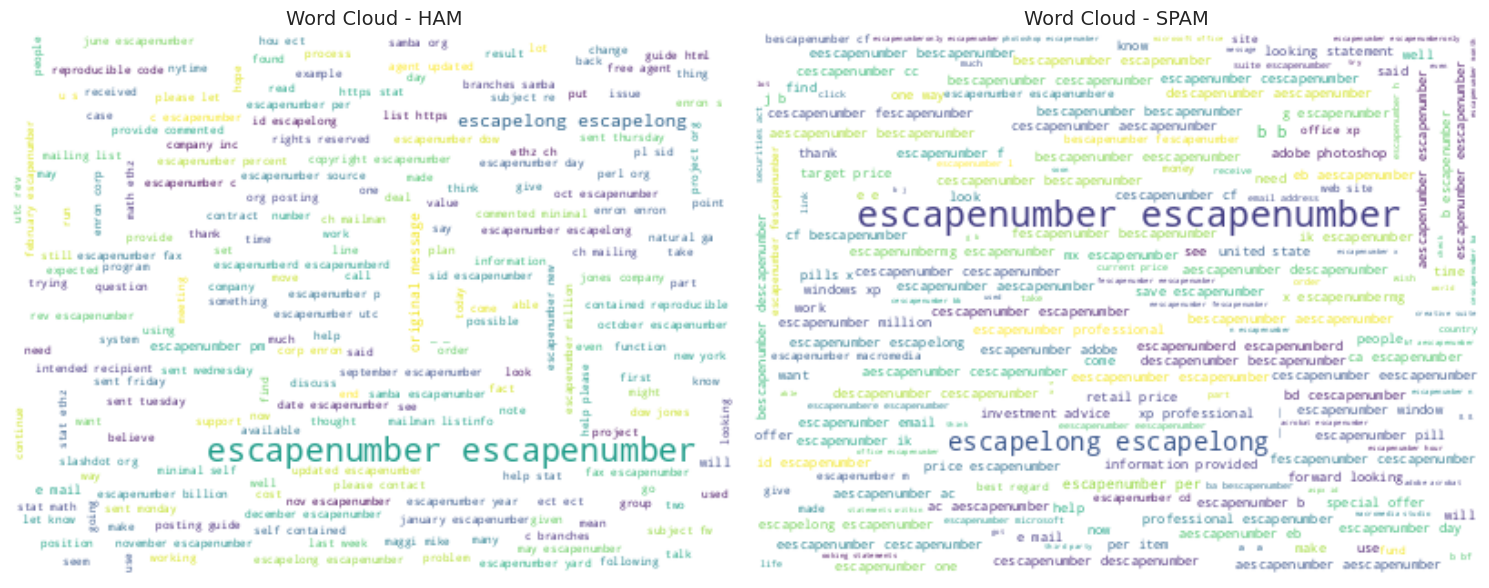

In [49]:

from collections import Counter
import re

def get_top_words(texts, n=20):
    # Combine all texts, lowercase, split into words
    all_words = ' '.join(texts).lower().split()
    # Remove punctuation (optional) – keep only alphabetic
    all_words = [re.sub(r'[^a-zA-Z]', '', w) for w in all_words]
    all_words = [w for w in all_words if len(w) > 2]  # ignore very short words
    return Counter(all_words).most_common(n)

print("Top 15 words in SPAM emails:")
spam_texts = df[df['label']=='Spam']['text']
for word, count in get_top_words(spam_texts, 15):
    print(f"  {word}: {count}")

print("\nTop 15 words in HAM emails:")
ham_texts = df[df['label']=='Ham']['text']
for word, count in get_top_words(ham_texts, 15):
    print(f"  {word}: {count}")


from wordcloud import WordCloud
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, label in zip(axes, ['Ham', 'Spam']):
    text = ' '.join(df[df['label'] == label]['text'])
    wc = WordCloud(width=400, height=300, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud - {label.upper()}', fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Text Preprocessing & Feature Extraction

In [64]:
df['label'] = df['label'].astype(str).str.lower().str.strip()

print(f"After label cleaning, dataset shape: {df.shape}")

import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\S*@\S*\s?', '', text)       # remove emails
    text = re.sub(r'http\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     # keep only letters and spaces
    text = ' '.join(text.split())                # collapse multiple spaces
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
print("Text cleaning completed.")

# 2. Encode labels: Ham -> 0, Spam -> 1 (now safe)
y = df['label'].map({'ham': 0, 'spam': 1})
print(f"Target distribution:\n{y.value_counts()}")

# Check for NaN in y (should be none)
if y.isna().any():
    print("WARNING: NaN values in y. Dropping those rows...")
    df = df[~y.isna()]
    y = y.dropna()
    print(f"New dataset shape: {df.shape}")

# 3. Convert text to TF\u2011IDF features
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X = vectorizer.fit_transform(df['cleaned_text'])   # keep sparse
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features (words/ngrams): {X.shape[1]}")

# 4. Train-test split (stratify to preserve class balance)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")
print(f"Training class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test class distribution:\n{pd.Series(y_test).value_counts()}")

After label cleaning, dataset shape: (193852, 5)
Text cleaning completed.
Target distribution:
label
0    102160
1     91692
Name: count, dtype: int64
Feature matrix shape: (193852, 10000)
Number of features (words/ngrams): 10000

Training set size: 155081 samples
Testing set size:  38771 samples
Training class distribution:
label
0    81728
1    73353
Name: count, dtype: int64
Test class distribution:
label
0    20432
1    18339
Name: count, dtype: int64


## Model Training and Evaluation – Perceptron

PERCEPTRON MODEL TRAINING AND EVALUATION

--- Performance Metrics ---
Accuracy:  0.9727
Precision (spam): 0.9721
Recall (spam):    0.9701
F1-Score (spam):  0.9711

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.98      0.97     20432
        Spam       0.97      0.97      0.97     18339

    accuracy                           0.97     38771
   macro avg       0.97      0.97      0.97     38771
weighted avg       0.97      0.97      0.97     38771



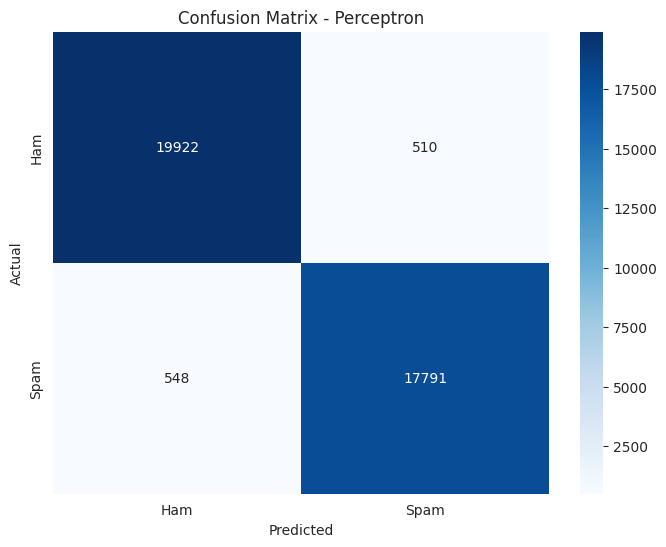

ROC‑AUC Score: 0.9958


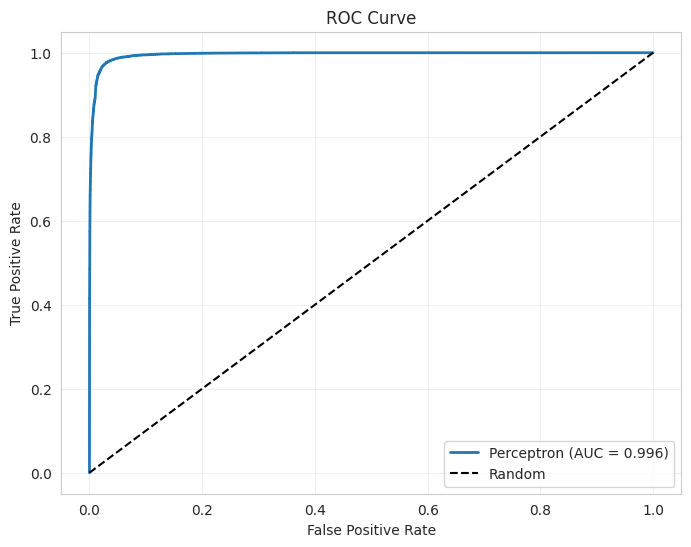

In [56]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the Perceptron (remove learning_rate for older sklearn versions)
perceptron = Perceptron(eta0=0.01, max_iter=1000, random_state=42)
perceptron.fit(X_train, y_train)

# 2. Predict on test set
y_pred = perceptron.predict(X_test)

# 3. Evaluate performance
print("\n--- Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (spam): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (spam):    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score (spam):  {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Perceptron')
plt.show()

# 5. ROC‑AUC (Perceptron provides decision_function for scores)
y_scores = perceptron.decision_function(X_test)
auc = roc_auc_score(y_test, y_scores)
print(f"ROC‑AUC Score: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_scores)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Perceptron (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Visualising Perceptron Evaluation Scores

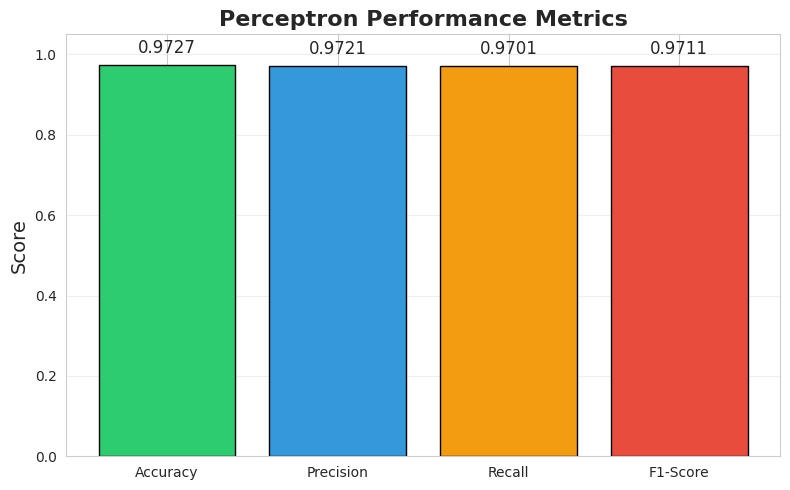

In [57]:
# Optional: Bar chart of performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'], edgecolor='black')
plt.title('Perceptron Performance Metrics', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1.05)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Misclassification analysis
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("="*50)
print("MISCLASSIFICATION BREAKDOWN")
print("="*50)
print(f"True Negatives (correct Ham):     {tn}")
print(f"True Positives (correct Spam):    {tp}")
print(f"False Negatives (missed Spam):    {fn}")
print(f"False Positives (ham wrongly flagged as spam): {fp}")
print(f"\nTotal misclassified: {fp + fn} out of {len(y_test)} ({((fp+fn)/len(y_test))*100:.2f}%)")

MISCLASSIFICATION BREAKDOWN
True Negatives (correct Ham):     19922
True Positives (correct Spam):    17791
False Negatives (missed Spam):    548
False Positives (ham wrongly flagged as spam): 510

Total misclassified: 1058 out of 38771 (2.73%)


In [59]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_acc = accuracy_score(y_test, dummy_pred)
print(f"Baseline (always predict majority class) accuracy: {dummy_acc:.4f}")
print(f"Perceptron accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Improvement: {accuracy_score(y_test, y_pred) - dummy_acc:.4f}")

Baseline (always predict majority class) accuracy: 0.5270
Perceptron accuracy: 0.9727
Improvement: 0.4457


In [70]:
# ============================================================
# TEST WITH CUSTOM EMAIL EXAMPLES
# ============================================================

print("="*60)
print("CLASSIFYING NEW EMAIL EXAMPLES")
print("="*60)

# Function to classify any email (reuse your clean_text function)
def classify_email(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = perceptron.predict(vec)[0]
    score = perceptron.decision_function(vec)[0]
    label = 'SPAM' if pred == 1 else 'HAM'
    return label, score

# List of example emails to test
example_emails = [
    # Spam examples
    "Congratulations! You've won a free iPhone 15. Click here to claim your prize now!",
    "URGENT: Your bank account has been compromised. Verify your details immediately at this link.",
    "Earn $5000 per week working from home. No experience needed. Sign up today!",

    # Ham examples
    "Hi Sarah, Are we still meeting for coffee tomorrow at 3pm? Let me know.",
    "Please find attached the quarterly report as requested. Let me know if you have any questions.",
    "Reminder: Team meeting at 10am in conference room B. Bring your laptops."
]

# Classify each email
for i, email in enumerate(example_emails, 1):
    label, score = classify_email(email)
    print(f"\n--- Email {i} ---")
    print(f"Text: {email[:80]}...")
    print(f"Classification: {label}")
    print(f"Confidence score: {score:.4f} (positive = spam, negative = ham)")

CLASSIFYING NEW EMAIL EXAMPLES

--- Email 1 ---
Text: Congratulations! You've won a free iPhone 15. Click here to claim your prize now...
Classification: SPAM
Confidence score: 0.0011 (positive = spam, negative = ham)

--- Email 2 ---
Text: URGENT: Your bank account has been compromised. Verify your details immediately ...
Classification: SPAM
Confidence score: 0.0017 (positive = spam, negative = ham)

--- Email 3 ---
Text: Earn $5000 per week working from home. No experience needed. Sign up today!...
Classification: HAM
Confidence score: -0.0002 (positive = spam, negative = ham)

--- Email 4 ---
Text: Hi Sarah, Are we still meeting for coffee tomorrow at 3pm? Let me know....
Classification: HAM
Confidence score: -0.0016 (positive = spam, negative = ham)

--- Email 5 ---
Text: Please find attached the quarterly report as requested. Let me know if you have ...
Classification: HAM
Confidence score: -0.0012 (positive = spam, negative = ham)

--- Email 6 ---
Text: Reminder: Team meeting at